# PoPE

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments
from datasets import load_dataset
import math

In [2]:
model_name = "timinar/baby-llama-58m"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_pope = AutoModelForCausalLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/104 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/233M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/147 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [3]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")


def tokenize(example):
    return tokenizer(example["text"], truncation=True, max_length=512)

tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])

def filter_empty(example):
    return len(example["input_ids"]) > 0

tokenized = tokenized.filter(filter_empty)

train = tokenized["train"]
val = tokenized["validation"]

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4358 [00:00<?, ? examples/s]

Filter:   0%|          | 0/36718 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [4]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [5]:
import csv
from transformers import TrainerCallback

class GPUStatsCallback(TrainerCallback):
    def __init__(self, filename="gpu_log.csv"):
        self.filename = filename

        with open(self.filename, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["step", "allocated_GB", "reserved_GB", "max_allocated_GB", "time"])

    def on_log(self, args, state, control, logs=None, **kwargs):
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated() / 1024**3
            reserved = torch.cuda.memory_reserved() / 1024**3
            max_allocated = torch.cuda.max_memory_allocated() / 1024**3

            with open(self.filename, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    state.global_step,
                    allocated,
                    reserved,
                    max_allocated,
                    time.time()
                ])

изучаем перплексию в зависимости от длины контекста

In [6]:
# def tokenize(example, max_length):
#     return tokenizer(
#         example["text"],
#         truncation=True,
#         max_length=max_length,
#         padding="max_length"
#     )

# def prepare_dataset(max_length):
#     tokenized = dataset.map(
#         lambda x: tokenize(x, max_length),
#         batched=True,
#         remove_columns=["text"]
#     )

#     def filter_empty(example):
#         return len(example["input_ids"]) > 0

#     tokenized = tokenized.filter(filter_empty)

#     train = tokenized["train"].select(range(2000))   # уменьшаем для скорости
#     val = tokenized["validation"].select(range(500))

#     return train, val


# def run_experiment(max_length, use_pope=False):
#     print(f"\n=== Context: {max_length} | PoPE: {use_pope} ===")

#     # модель
#     model = AutoModelForCausalLM.from_pretrained(model_name)

#     # 👉 применяем PoPE если нужно
#     if use_pope:
#         from transformers.models.llama import modeling_llama
#         modeling_llama.apply_rotary_pos_emb = patched_apply_rotary_pos_emb

#     train, val = prepare_dataset(max_length)

#     training_args = TrainingArguments(
#         output_dir=f"./test_{max_length}_{use_pope}",
#         per_device_train_batch_size=1,
#         num_train_epochs=1,
#         logging_steps=100
#     )

#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train,
#         eval_dataset=val,
#         data_collator=data_collator
#     )

#     trainer.train()

#     eval_result = trainer.evaluate()
#     ppl = math.exp(eval_result["eval_loss"])

#     print(f"Perplexity: {ppl}")
#     return ppl


# results = []

# for ctx in [128, 256, 512, 1024]:
#     ppl_rope = run_experiment(ctx, use_pope=False)
#     # ppl_pope = run_experiment(ctx, use_pope=True)

#     results.append((ctx, ppl_rope))

# # for ctx, rope, pope in results:
# for ctx, rope in results:
#     print(f"Context {ctx}: RoPE={rope:.2f}")

# import matplotlib.pyplot as plt

# contexts = [r[0] for r in results]
# rope_vals = [r[1] for r in results]
# # pope_vals = [r[2] for r in results]

# plt.plot(contexts, rope_vals, label="RoPE")
# # plt.plot(contexts, pope_vals, label="PoPE")

# plt.xlabel("Context Length")
# plt.ylabel("Perplexity")
# plt.title("RoPE vs PoPE (Long Context)")
# plt.legend()
# plt.show()

In [7]:
import torch
from transformers.models.llama import modeling_llama

def rotate_half(x):
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

def apply_pope(q, k, cos, sin, position_ids):

    if position_ids is None:
        position_ids = torch.arange(q.shape[-2], device=q.device).unsqueeze(0)

    pos = position_ids.float()

    r = torch.log(pos + 1).unsqueeze(-1)
    theta = pos / 10000

    cos = torch.cos(theta).unsqueeze(-1)
    sin = torch.sin(theta).unsqueeze(-1)

    q = r * (q * cos + rotate_half(q) * sin)
    k = r * (k * cos + rotate_half(k) * sin)

    return q, k

original_apply_rope = modeling_llama.apply_rotary_pos_emb

def patched_apply_rotary_pos_emb(q, k, cos, sin, position_ids=None):
    return apply_pope(q, k, cos, sin, position_ids)

modeling_llama.apply_rotary_pos_emb = patched_apply_rotary_pos_emb

#train pope

In [9]:
import time

training_args_pope = TrainingArguments(
    output_dir="./pope",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=32,

    per_device_eval_batch_size=1,

    max_steps=5000,

    num_train_epochs=2,
    logging_steps=50,
    save_steps=500,
    # per_device_train_batch_size=2,
    # per_device_eval_batch_size=1,
    # num_train_epochs=2,
    # logging_steps=50,
    # save_steps=500,
)

trainer_pope = Trainer(
    model=model_pope,
    args=training_args_pope,
    train_dataset=train,
    eval_dataset=val,
    data_collator=data_collator,
    callbacks=[GPUStatsCallback()]
)

trainer_pope.train()

Step,Training Loss
50,5.006611
100,4.940975
150,4.878370
200,4.817856
250,4.742310
300,4.727091
350,4.683017
400,4.614483
450,4.569960
500,4.569757


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=4.04233023071289, metrics={'train_runtime': 11439.6314, 'train_samples_per_second': 27.973, 'train_steps_per_second': 0.437, 'total_flos': 1.6056371805659136e+16, 'train_loss': 4.04233023071289, 'epoch': 13.44160215415685})

#перплексия

In [13]:
eval_pope = trainer_pope.evaluate()
ppl_pope = math.exp(eval_pope["eval_loss"])

print("PoPE perplexity:", ppl_pope)

PoPE perplexity: 44.875356800370014


In [15]:
print("Eval res pope:", eval_pope)

Eval res pope: {'eval_loss': 3.8038887977600098, 'eval_runtime': 94.6912, 'eval_samples_per_second': 25.99, 'eval_steps_per_second': 25.99, 'epoch': 13.44160215415685}


#mmlu

один датасет

In [16]:
dataset = load_dataset("cais/mmlu", "abstract_algebra", split="test")

def format_question(model, example):
    question = example["question"]
    choices = example["choices"]

    prompt = question + "\n"
    for i, choice in enumerate(choices):
        prompt += f"{chr(65+i)}. {choice}\n"

    prompt += "Answer:"
    return prompt, example["answer"]

def get_answer(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return text


def evaluate_mmlu(model, dataset, n_samples=50):
    correct = 0

    for i in range(n_samples):
        prompt, label = format_question(model, dataset[i])
        output = get_answer(model, prompt)

        predicted = output.strip()[-1]  # последняя буква

        if predicted in ["A", "B", "C", "D"]:
            pred_idx = ord(predicted) - ord("A")
            if pred_idx == label:
                correct += 1

    acc = correct / n_samples
    print(f"Accuracy: {acc:.2f}")

    return acc

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

abstract_algebra/test-00000-of-00001.par(…):   0%|          | 0.00/9.96k [00:00<?, ?B/s]

abstract_algebra/validation-00000-of-000(…):   0%|          | 0.00/3.73k [00:00<?, ?B/s]

abstract_algebra/dev-00000-of-00001.parq(…):   0%|          | 0.00/3.45k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

In [17]:
pope_acc = evaluate_mmlu(model_pope, dataset)

Accuracy: 0.00


несколько

In [18]:
subjects = [
    "abstract_algebra",
    "high_school_physics",
    "computer_security",
    "astronomy",
    "philosophy",
    "high_school_computer_science",
    "college_mathematics",
    "machine_learning"
]

datasets_mmlu = {}

for subject in subjects:
    datasets_mmlu[subject] = load_dataset(
        "cais/mmlu",
        subject,
        split="test"
    )

summ = 0

for subject, dataset in datasets_mmlu.items():
    print(f"\n=== {subject} ===")

    # test_cases = build_test_cases(dataset, n_samples=20)
    # acc = mmlu_accuracy(test_cases)

    acc = evaluate_mmlu(model_pope, dataset)
    summ += acc

    print("Accuracy:", acc)

print("Sum accurasy: ", summ)

high_school_physics/test-00000-of-00001.(…):   0%|          | 0.00/33.0k [00:00<?, ?B/s]

high_school_physics/validation-00000-of-(…):   0%|          | 0.00/7.96k [00:00<?, ?B/s]

high_school_physics/dev-00000-of-00001.p(…):   0%|          | 0.00/4.57k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/151 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/17 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/11 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]


=== abstract_algebra ===
Accuracy: 0.00
Accuracy: 0.0

=== high_school_physics ===


Token indices sequence length is longer than the specified maximum sequence length for this model (189 > 128). Running this sequence through the model will result in indexing errors
This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (256). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


Accuracy: 0.00
Accuracy: 0.0

=== computer_security ===
Accuracy: 0.00
Accuracy: 0.0

=== astronomy ===
Accuracy: 0.00
Accuracy: 0.0

=== philosophy ===
Accuracy: 0.00
Accuracy: 0.0

=== high_school_computer_science ===
Accuracy: 0.00
Accuracy: 0.0

=== college_mathematics ===
Accuracy: 0.00
Accuracy: 0.0

=== machine_learning ===
Accuracy: 0.00
Accuracy: 0.0
Sum accurasy:  0.0


#niah


Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branc

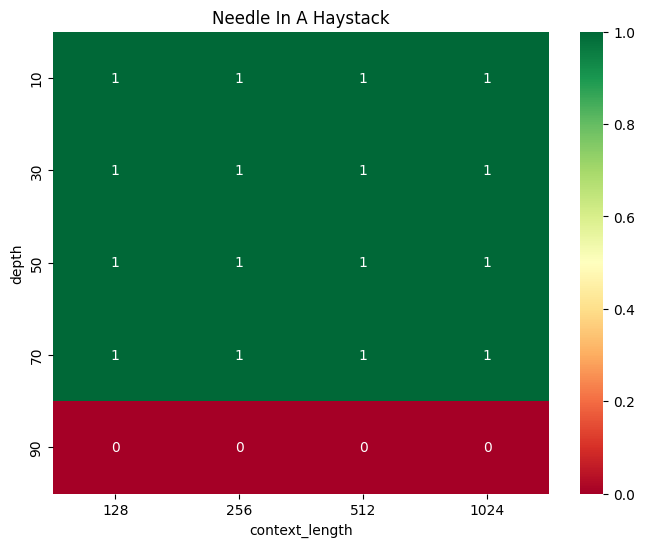

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

haystack = """
Machine learning is a branch of AI.
Transformers use attention mechanisms.
Neural networks process tensors.
""" * 200

needle = "The secret passcode is 8472."

def insert_needle(text, needle, depth_percent=50):
    words = text.split()

    insert_idx = int(len(words) * depth_percent / 100)

    words.insert(insert_idx, needle)

    return " ".join(words)

context = insert_needle(
    haystack,
    needle,
    depth_percent=50
)

question = "What is the secret passcode?"

prompt = f"""
{context}

Question: {question}
Answer:
"""


inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=1024
).to(model_pope.device)

outputs = model_pope.generate(
    **inputs,
    max_new_tokens=20
)

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(response)


if "8472" in response:
    print("PASS")
else:
    print("FAIL")

context_lengths = [128, 256, 512, 1024]
depths = [10, 30, 50, 70, 90]


results = []

for context_len in context_lengths:

    truncated_haystack = haystack[:context_len * 5]

    for depth in depths:

        context = insert_needle(
            truncated_haystack,
            needle,
            depth
        )

        prompt = f"""
        {context}

        Question: What is the secret passcode?
        Answer:
        """

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=context_len
        ).to(model_pope.device)

        outputs = model_pope.generate(
            **inputs,
            max_new_tokens=20
        )

        response = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

        passed = "8472" in response

        results.append({
            "context_length": context_len,
            "depth": depth,
            "success": int(passed)
        })

        print(context_len, depth, passed)




df = pd.DataFrame(results)

pivot = df.pivot(
    index="depth",
    columns="context_length",
    values="success"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn"
)

plt.title("Needle In A Haystack")
plt.show()

niah в зависимости от длины

context=128 depth=10 run=1 success=True
context=128 depth=10 run=2 success=True
context=128 depth=10 run=3 success=True
context=128 depth=10 run=4 success=True
context=128 depth=10 run=5 success=True
FINAL -> context=128 depth=10 accuracy=1.0
context=128 depth=30 run=1 success=True
context=128 depth=30 run=2 success=True
context=128 depth=30 run=3 success=True
context=128 depth=30 run=4 success=True
context=128 depth=30 run=5 success=True
FINAL -> context=128 depth=30 accuracy=1.0
context=128 depth=50 run=1 success=True
context=128 depth=50 run=2 success=True
context=128 depth=50 run=3 success=True
context=128 depth=50 run=4 success=True
context=128 depth=50 run=5 success=True
FINAL -> context=128 depth=50 accuracy=1.0
context=128 depth=70 run=1 success=True
context=128 depth=70 run=2 success=True
context=128 depth=70 run=3 success=True
context=128 depth=70 run=4 success=True
context=128 depth=70 run=5 success=True
FINAL -> context=128 depth=70 accuracy=1.0
context=128 depth=90 run=1 s

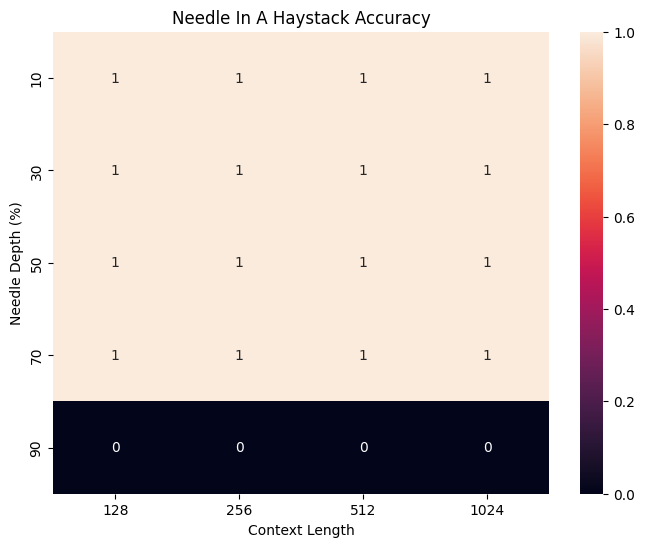

In [20]:
import random

needle = "The secret passcode is 8472."

question = "What is the secret passcode?"

# длинный текст
haystack = """
Machine learning is a branch of AI.
Transformers use attention mechanisms.
Neural networks process tensors.
Large language models use positional embeddings.
""" * 500


def run_niah_test(model, tokenizer, context_length, depth,):
    # обрезаем текст под нужный контекст
    truncated = haystack[:context_length * 5]

    context = insert_needle(
        truncated,
        needle,
        depth
    )

    prompt = f"""
    {context}

    Question: {question}
    Answer:
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=context_length
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    success = "8472" in response

    return success


# параметры benchmark
context_lengths = [128, 256, 512, 1024]
depths = [10, 30, 50, 70, 90]

# сколько запусков на каждую комбинацию
n_runs = 5

results = []

for context_length in context_lengths:

    for depth in depths:

        successes = 0

        for run in range(n_runs):

            ok = run_niah_test(
                model_pope,
                tokenizer,
                context_length,
                depth
            )

            successes += int(ok)

            print(
                f"context={context_length} "
                f"depth={depth} "
                f"run={run+1} "
                f"success={ok}"
            )

        accuracy = successes / n_runs

        results.append({
            "context_length": context_length,
            "depth": depth,
            "accuracy": accuracy
        })

        print(
            f"FINAL -> context={context_length} "
            f"depth={depth} "
            f"accuracy={accuracy}"
        )

# dataframe
df = pd.DataFrame(results)

print(df)

# heatmap
pivot = df.pivot(
    index="depth",
    columns="context_length",
    values="accuracy"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    vmin=0,
    vmax=1
)

plt.title("Needle In A Haystack Accuracy")
plt.ylabel("Needle Depth (%)")
plt.xlabel("Context Length")

plt.show()

#LRA

context=128 depth=10 question=What is the retrieval key? success=True
context=128 depth=10 question=What is the hidden city? success=True
context=128 depth=10 question=What is the experiment year? success=True
FINAL: context=128 depth=10 accuracy=1.0
context=128 depth=30 question=What is the retrieval key? success=True
context=128 depth=30 question=What is the hidden city? success=True
context=128 depth=30 question=What is the experiment year? success=True
FINAL: context=128 depth=30 accuracy=1.0
context=128 depth=50 question=What is the retrieval key? success=True
context=128 depth=50 question=What is the hidden city? success=True
context=128 depth=50 question=What is the experiment year? success=True
FINAL: context=128 depth=50 accuracy=1.0
context=128 depth=70 question=What is the retrieval key? success=True
context=128 depth=70 question=What is the hidden city? success=True
context=128 depth=70 question=What is the experiment year? success=True
FINAL: context=128 depth=70 accuracy=

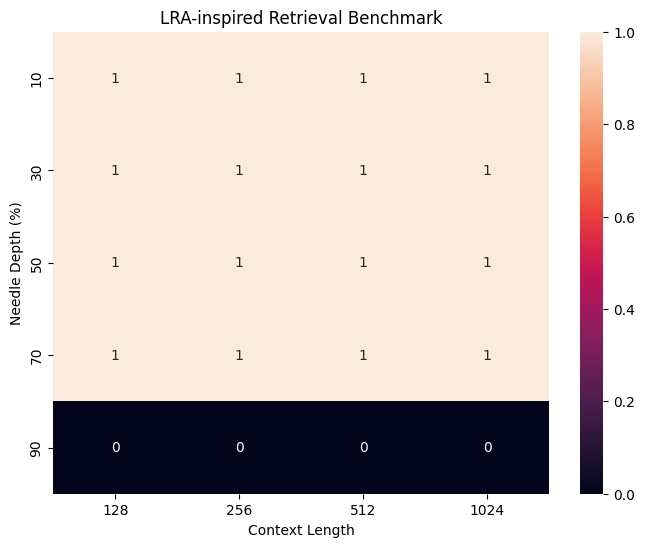

In [21]:
import torch

base_text = """
Transformers are neural architectures based on attention.
Large language models use positional embeddings.
Rotary Position Embedding improves positional encoding.
Polar Coordinate Positional Embedding is designed
for better long-context extrapolation.
""" * 400

facts = [
    ("The retrieval key is ALPHA-8472", "What is the retrieval key?", "ALPHA-8472"),
    ("The hidden city is Amsterdam", "What is the hidden city?", "Amsterdam"),
    ("The experiment year is 2025", "What is the experiment year?", "2025"),
]


def insert_fact(text, fact, depth_percent):

    words = text.split()

    idx = int(len(words) * depth_percent / 100)

    words.insert(idx, fact)

    return " ".join(words)



def retrieval_test(
    model,
    tokenizer,
    context_length,
    depth,
    fact,
    question,
    answer,
):

    context = insert_fact(
        base_text[:context_length * 5],
        fact,
        depth
    )

    prompt = f"""
    {context}

    Question: {question}

    Answer:
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=context_length
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    success = answer.lower() in response.lower()

    return success, response


context_lengths = [128, 256, 512, 1024]

depths = [10, 30, 50, 70, 90]

results = []

for context_length in context_lengths:

    for depth in depths:

        total = 0
        correct = 0

        for fact, question, answer in facts:

            ok, response = retrieval_test(
                model_pope,
                tokenizer,
                context_length,
                depth,
                fact,
                question,
                answer
            )

            total += 1
            correct += int(ok)

            print(
                f"context={context_length} "
                f"depth={depth} "
                f"question={question} "
                f"success={ok}"
            )

        accuracy = correct / total

        results.append({
            "context_length": context_length,
            "depth": depth,
            "accuracy": accuracy
        })

        print(
            f"FINAL: context={context_length} "
            f"depth={depth} "
            f"accuracy={accuracy}"
        )

df = pd.DataFrame(results)

pivot = df.pivot(
    index="depth",
    columns="context_length",
    values="accuracy"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    vmin=0,
    vmax=1
)

plt.title("LRA-inspired Retrieval Benchmark")

plt.ylabel("Needle Depth (%)")
plt.xlabel("Context Length")

plt.show()

#RoPE

In [22]:
# !pip install transformers datasets accelerate

In [23]:
# !pip install -q datasets evaluate transformers accelerate

In [25]:
model_rope = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/147 [00:00<?, ?it/s]

In [26]:
modeling_llama.apply_rotary_pos_emb = original_apply_rope

#train rope

In [27]:
training_args = TrainingArguments(
    output_dir="./rope",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=32,

    per_device_eval_batch_size=1,

    max_steps=5000,

    num_train_epochs=2,
    logging_steps=50,
    save_steps=500,
)
#И BERT, и RoFormer обучаются с:
# batch size = 64
# максимальная длина последовательности = 512
# число шагов = 100k

trainer_rope = Trainer(
    model=model_rope,
    args=training_args,
    train_dataset=train,
    eval_dataset=val,
    data_collator=data_collator,
    callbacks=[GPUStatsCallback()]
)

trainer_rope.save_model("./rope_final")
tokenizer.save_pretrained("./rope_final")

start = time.perf_counter()

trainer_rope.train()

end = time.perf_counter()

print((end-start)/60)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss
50,4.489887
100,4.192450
150,4.130491
200,4.073673
250,4.020544
300,4.019822
350,3.971571
400,3.895833
450,3.829575
500,3.841817


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

186.55884753215


In [35]:
eval_rope = trainer_rope.evaluate()
ppl_rope = math.exp(eval_rope["eval_loss"])

print("RoPE perplexity:", ppl_rope)

RoPE perplexity: 46.79182970019864


In [29]:
print("Eval res rope:", eval_rope)

Eval res rope: {'eval_loss': 4.168636322021484, 'eval_runtime': 51.751, 'eval_samples_per_second': 47.555, 'eval_steps_per_second': 47.555, 'epoch': 13.44160215415685}


#mmlu

In [30]:
dataset = load_dataset("cais/mmlu", "abstract_algebra", split="test")

rope_acc = evaluate_mmlu(model_rope, dataset)

Accuracy: 0.02


In [31]:
sum_rope = 0

for subject, dataset in datasets_mmlu.items():
    print(f"\n=== {subject} ===")

    # test_cases = build_test_cases(dataset, n_samples=20)
    # acc = mmlu_accuracy(test_cases)

    acc = evaluate_mmlu(model_rope, dataset)
    sum_rope += acc

    print("Accuracy:", acc)

print("Sum accurasy: ", sum_rope)


=== abstract_algebra ===
Accuracy: 0.02
Accuracy: 0.02

=== high_school_physics ===
Accuracy: 0.00
Accuracy: 0.0

=== computer_security ===
Accuracy: 0.04
Accuracy: 0.04

=== astronomy ===
Accuracy: 0.00
Accuracy: 0.0

=== philosophy ===
Accuracy: 0.06
Accuracy: 0.06

=== high_school_computer_science ===
Accuracy: 0.04
Accuracy: 0.04

=== college_mathematics ===
Accuracy: 0.02
Accuracy: 0.02

=== machine_learning ===
Accuracy: 0.00
Accuracy: 0.0
Sum accurasy:  0.18


#niah


Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branch of AI. Transformers use attention mechanisms. Neural networks process tensors. Machine learning is a branc

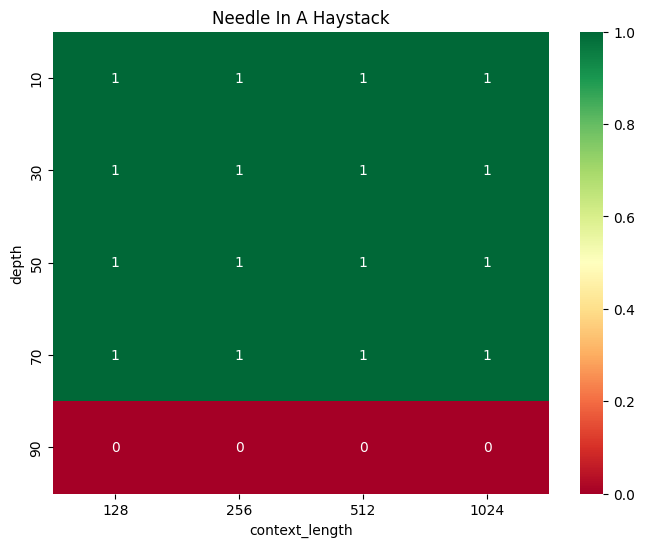

In [32]:
haystack = """
Machine learning is a branch of AI.
Transformers use attention mechanisms.
Neural networks process tensors.
""" * 200

needle = "The secret passcode is 8472."

context = insert_needle(
    haystack,
    needle,
    depth_percent=50
)

question = "What is the secret passcode?"

prompt = f"""
{context}

Question: {question}
Answer:
"""


inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=1024
).to(model_rope.device)

outputs = model_rope.generate(
    **inputs,
    max_new_tokens=20
)

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(response)


if "8472" in response:
    print("PASS")
else:
    print("FAIL")

context_lengths = [128, 256, 512, 1024]
depths = [10, 30, 50, 70, 90]


results = []

for context_len in context_lengths:

    truncated_haystack = haystack[:context_len * 5]

    for depth in depths:

        context = insert_needle(
            truncated_haystack,
            needle,
            depth
        )

        prompt = f"""
        {context}

        Question: What is the secret passcode?
        Answer:
        """

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=context_len
        ).to(model_rope.device)

        outputs = model_rope.generate(
            **inputs,
            max_new_tokens=20
        )

        response = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

        passed = "8472" in response

        results.append({
            "context_length": context_len,
            "depth": depth,
            "success": int(passed)
        })

        print(context_len, depth, passed)




df = pd.DataFrame(results)

pivot = df.pivot(
    index="depth",
    columns="context_length",
    values="success"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn"
)

plt.title("Needle In A Haystack")
plt.show()

niah в зависимости от длины

context=128 depth=10 run=1 success=True
context=128 depth=10 run=2 success=True
context=128 depth=10 run=3 success=True
context=128 depth=10 run=4 success=True
context=128 depth=10 run=5 success=True
FINAL -> context=128 depth=10 accuracy=1.0
context=128 depth=30 run=1 success=True
context=128 depth=30 run=2 success=True
context=128 depth=30 run=3 success=True
context=128 depth=30 run=4 success=True
context=128 depth=30 run=5 success=True
FINAL -> context=128 depth=30 accuracy=1.0
context=128 depth=50 run=1 success=True
context=128 depth=50 run=2 success=True
context=128 depth=50 run=3 success=True
context=128 depth=50 run=4 success=True
context=128 depth=50 run=5 success=True
FINAL -> context=128 depth=50 accuracy=1.0
context=128 depth=70 run=1 success=True
context=128 depth=70 run=2 success=True
context=128 depth=70 run=3 success=True
context=128 depth=70 run=4 success=True
context=128 depth=70 run=5 success=True
FINAL -> context=128 depth=70 accuracy=1.0
context=128 depth=90 run=1 s

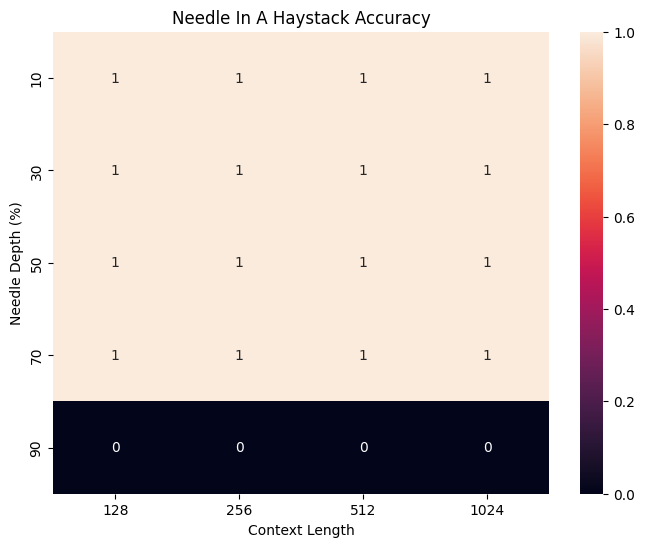

In [33]:
needle = "The secret passcode is 8472."

question = "What is the secret passcode?"

# длинный текст
haystack = """
Machine learning is a branch of AI.
Transformers use attention mechanisms.
Neural networks process tensors.
Large language models use positional embeddings.
""" * 500

# параметры benchmark
context_lengths = [128, 256, 512, 1024]
depths = [10, 30, 50, 70, 90]

# сколько запусков на каждую комбинацию
n_runs = 5

results = []

for context_length in context_lengths:

    for depth in depths:

        successes = 0

        for run in range(n_runs):

            ok = run_niah_test(
                model_rope,
                tokenizer,
                context_length,
                depth
            )

            successes += int(ok)

            print(
                f"context={context_length} "
                f"depth={depth} "
                f"run={run+1} "
                f"success={ok}"
            )

        accuracy = successes / n_runs

        results.append({
            "context_length": context_length,
            "depth": depth,
            "accuracy": accuracy
        })

        print(
            f"FINAL -> context={context_length} "
            f"depth={depth} "
            f"accuracy={accuracy}"
        )

# dataframe
df = pd.DataFrame(results)

print(df)

# heatmap
pivot = df.pivot(
    index="depth",
    columns="context_length",
    values="accuracy"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    vmin=0,
    vmax=1
)

plt.title("Needle In A Haystack Accuracy")
plt.ylabel("Needle Depth (%)")
plt.xlabel("Context Length")

plt.show()

#lra

context=128 depth=10 question=What is the retrieval key? success=True
context=128 depth=10 question=What is the hidden city? success=True
context=128 depth=10 question=What is the experiment year? success=True
FINAL: context=128 depth=10 accuracy=1.0
context=128 depth=30 question=What is the retrieval key? success=True
context=128 depth=30 question=What is the hidden city? success=True
context=128 depth=30 question=What is the experiment year? success=True
FINAL: context=128 depth=30 accuracy=1.0
context=128 depth=50 question=What is the retrieval key? success=True
context=128 depth=50 question=What is the hidden city? success=True
context=128 depth=50 question=What is the experiment year? success=True
FINAL: context=128 depth=50 accuracy=1.0
context=128 depth=70 question=What is the retrieval key? success=True
context=128 depth=70 question=What is the hidden city? success=True
context=128 depth=70 question=What is the experiment year? success=True
FINAL: context=128 depth=70 accuracy=

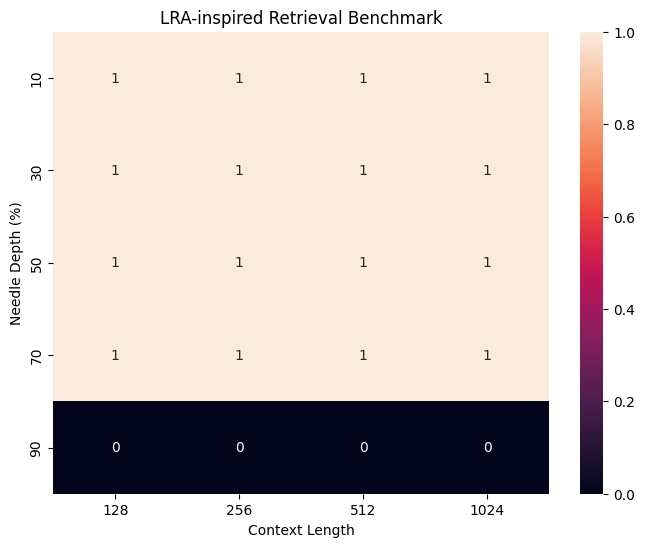

In [34]:
import torch

base_text = """
Transformers are neural architectures based on attention.
Large language models use positional embeddings.
Rotary Position Embedding improves positional encoding.
Polar Coordinate Positional Embedding is designed
for better long-context extrapolation.
""" * 400

facts = [
    ("The retrieval key is ALPHA-8472", "What is the retrieval key?", "ALPHA-8472"),
    ("The hidden city is Amsterdam", "What is the hidden city?", "Amsterdam"),
    ("The experiment year is 2025", "What is the experiment year?", "2025"),
]


context_lengths = [128, 256, 512, 1024]

depths = [10, 30, 50, 70, 90]

results = []

for context_length in context_lengths:

    for depth in depths:

        total = 0
        correct = 0

        for fact, question, answer in facts:

            ok, response = retrieval_test(
                model_rope,
                tokenizer,
                context_length,
                depth,
                fact,
                question,
                answer
            )

            total += 1
            correct += int(ok)

            print(
                f"context={context_length} "
                f"depth={depth} "
                f"question={question} "
                f"success={ok}"
            )

        accuracy = correct / total

        results.append({
            "context_length": context_length,
            "depth": depth,
            "accuracy": accuracy
        })

        print(
            f"FINAL: context={context_length} "
            f"depth={depth} "
            f"accuracy={accuracy}"
        )

df = pd.DataFrame(results)

pivot = df.pivot(
    index="depth",
    columns="context_length",
    values="accuracy"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    vmin=0,
    vmax=1
)

plt.title("LRA-inspired Retrieval Benchmark")

plt.ylabel("Needle Depth (%)")
plt.xlabel("Context Length")

plt.show()